# R07-H47 - entity growth must saturate: the Heaps exponent as a resolution health metric

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-06 <br>
**Pipeline stage**: R07 contrarian slate, completion-free set <br>
**Graph**: R05 campaign wave 1b (neo4j3), mid-wave snapshot - interim fit, final at wave end <br>

A fixed domain has finite entities, so a working resolution pipeline must show Heaps-law flattening in the cumulative distinct-entity count as the corpus grows. Sustained linear growth (exponent b -> 1.0) means resolution is leaking duplicates. The exponent is corpus-size-independent - the structural sibling of the H32 missing-mass gate, applied to entities instead of types.

Cumulative entity vocabulary follows Heaps' law:

$$V(n) = K \cdot n^{b}$$

where n = documents ingested, V = distinct entities, and b<1 indicates saturation (log-log linear fit).

## Approach
1. **Load** - documents in ingest order (`KGFDocument.created_at`), each entity's first-seen position = earliest of its `source_documents`
2. **Fit** - log-log least squares over the realized curve (n >= 5), plus a windowed fit to see whether b drifts
3. **Verdict** - against the pre-registered bar: b < 0.9 predicted; the premature-run comparison clause is not computable (that graph was wiped; only type-level observations were preserved) - recorded as a scope limitation

## Outputs
- `reports/entity-growth-h47-<stamp>.json` - fitted exponents, curve points
- In-notebook: growth curve with fit overlay, windowed-exponent track

In [1]:
# Imports
# stdlib
import datetime  # report stamps
import json  # report persistence
import os  # graph selection env

# third party
import numpy as np  # log-log fit
import matplotlib.pyplot as plt  # growth curve
from pathlib import Path
from rich import print as rprint  # semantic output

os.environ["NEO4J_URI"] = "bolt://user-konrad.jelen-kgf-neo4j3:7687"
os.environ["NEO4J_USER"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "kgfoundry"

# project
from neo4j import GraphDatabase  # direct read-only queries

In [2]:
# Configuration
FIT_MIN_N = 5          # skip the noisy head of the curve
WINDOW = 30            # docs per windowed-exponent segment
BAR_EXPONENT = 0.9     # pre-registered: b < 0.9 = saturating resolution

rprint(f"""[bold cyan]Configuration[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
[bold]Graph[/bold]
  Neo4j: [cyan]{os.environ['NEO4J_URI']}[/cyan] [dim](R05 wave 1b, mid-wave)[/dim]

[bold]Fit[/bold]
  Min n: [yellow]{FIT_MIN_N}[/yellow]  Window: [yellow]{WINDOW}[/yellow] docs
  Bar: b < [yellow]{BAR_EXPONENT}[/yellow]
""")

Configuration
────────────────────────────────────────
Graph
  Neo4j: bolt://user-konrad.jelen-kgf-neo4j3:7687 (R05 wave 1b, mid-wave)

Fit
  Min n: 5  Window: 30 docs
  Bar: b < 0.9

## Data loading

Documents ordered by `created_at` give ingest positions; each entity's first-seen position is the earliest position among its `source_documents`. The cumulative count of first-seen entities at each position is the realized V(n) curve - resolution merges collapse re-mentions into existing entities, so only genuinely-new identities advance the curve.

In [3]:
driver = GraphDatabase.driver(
    os.environ["NEO4J_URI"],
    auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"]),
    notifications_min_severity="OFF",
)
with driver.session() as s:
    docs = [r["id"] for r in s.run(
        "MATCH (d:KGFDocument) RETURN d.id AS id ORDER BY d.created_at"
    )]
    ents = s.run(
        "MATCH (e:Entity) WHERE e.source_documents IS NOT NULL "
        "RETURN e.id AS id, e.source_documents AS docs"
    ).data()
driver.close()

pos = {d: i for i, d in enumerate(docs)}
first_seen = np.zeros(len(docs), dtype=int)
unplaced = 0
for e in ents:
    ps = [pos[d] for d in (e["docs"] or []) if d in pos]
    if ps:
        first_seen[min(ps)] += 1
    else:
        unplaced += 1

V = np.cumsum(first_seen)
n = np.arange(1, len(docs) + 1)
rprint(
    f"docs: [yellow]{len(docs)}[/yellow]  entities: [yellow]{len(ents)}[/yellow] "
    f"([dim]{unplaced} without placeable provenance[/dim])  V(end): [yellow]{V[-1]}[/yellow]"
)

docs: 130  entities: 802 (0 without placeable provenance)  V(end): 802

## Fit, curve and verdict

Global log-log fit gives the headline exponent; the windowed fit tracks whether b drifts upward over the wave (rising b = resolution starting to leak). The interim verdict is against the b < 0.9 bar; the fit is re-run at wave end before the log verdict is finalized.

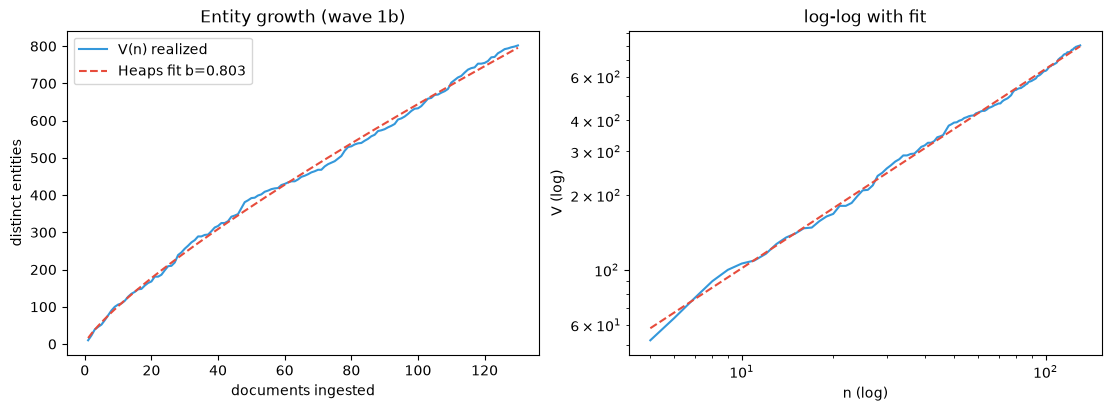

Heaps fit
────────────────────────────────────────
  Global exponent b: 0.803 (K=16.0, bar < 0.9)
  Windowed b: [{'docs': '6-35', 'b': 0.811}, {'docs': '36-65', 'b': 0.753}, {'docs': '66-95', 'b': 0.833}, {'docs':
'96-125', 'b': 0.966}]
  Verdict: CONFIRMED (interim) (final at wave end)

saved ../reports/entity-growth-h47-20260706-170431.json

In [4]:
mask = n >= FIT_MIN_N
b_global, logK = np.polyfit(np.log(n[mask]), np.log(V[mask]), 1)
K = float(np.exp(logK))

win_rows = []
for start in range(FIT_MIN_N, len(n) - WINDOW + 1, WINDOW):
    seg = slice(start, start + WINDOW)
    b_w, _ = np.polyfit(np.log(n[seg]), np.log(V[seg]), 1)
    win_rows.append({"docs": f"{start + 1}-{start + WINDOW}", "b": round(float(b_w), 3)})

verdict = "CONFIRMED (interim)" if b_global < BAR_EXPONENT else "REFUTED (interim)"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
ax1.plot(n, V, color="#3498DB", label="V(n) realized")
ax1.plot(n, K * n**b_global, "--", color="#E74C3C", label=f"Heaps fit b={b_global:.3f}")
ax1.set(xlabel="documents ingested", ylabel="distinct entities", title="Entity growth (wave 1b)")
ax1.legend()
ax2.loglog(n[mask], V[mask], color="#3498DB")
ax2.loglog(n[mask], K * n[mask]**b_global, "--", color="#E74C3C")
ax2.set(xlabel="n (log)", ylabel="V (log)", title="log-log with fit")
plt.show()

rprint(f"""[bold cyan]Heaps fit[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Global exponent b: [yellow]{b_global:.3f}[/yellow] [dim](K={K:.1f}, bar < {BAR_EXPONENT})[/dim]
  Windowed b: {win_rows}
  Verdict: [{'green' if b_global < BAR_EXPONENT else 'red'}]{verdict}[/] [dim](final at wave end)[/dim]
""")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"entity-growth-h47-{stamp}.json"
out.write_text(json.dumps({
    "docs": int(len(docs)), "entities": int(V[-1]), "b_global": float(b_global),
    "K": K, "windowed": win_rows, "verdict": verdict,
    "curve": {"n": n.tolist(), "V": V.tolist()},
}, indent=2))
rprint("saved", str(out))